## División del corups por párrafos

### Librerías

In [1]:
import spacy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from umap import UMAP


from sentence_transformers import CrossEncoder
from scipy.special import expit


nltk.download("punkt")
nltk.download('stopwords')
nlp = spacy.load("es_core_news_sm")
stop = stopwords.words('spanish')

/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1778172459.290922   49715 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778172460.914024   49715 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punk

### Funciones principales

In [ ]:
def cargar_datos(n_noticia,print_info=False):
    '''
    Cargar los datos del archivo de noticias limpio, sin lematizar, para poder aplicar sent_tokenize
    input: n_noticia (int): número de noticia a cargar
    '''

    # Esto mejor poenrlo fuera para que sea más eficiente
    with open("conjunto_noticias/conjunto_noticias_limpio.json", "r", encoding="utf-8") as f:
        noticias = json.load(f)

    noticia = noticias[n_noticia]
    titulo = noticia["Título"]
    # periodico= noticia["Periódico"]
    # Categoría = noticia["Categoría"]
    # subtitulo = noticia["Subtítulo"]
    contenido = noticia["Contenido"]
    fragmentos_contenido = sent_tokenize(contenido, language='spanish')
    corpus = [titulo] + fragmentos_contenido
    
    corpus_procesado = []

    for texto in corpus:

        doc = nlp(texto)
        tokens_limpios = [
            token.lemma_.lower()
            for token in doc
            if (
                not token.is_stop
                and not token.is_punct
                and not token.is_space
                and token.is_alpha
            )
        ]

        texto_procesado = " ".join(tokens_limpios)
        corpus_procesado.append(texto_procesado)

    if print_info:
        print(f"Título: {titulo}\n")
        print(f"\nFragmentos:")
        i=0
        for contenido in fragmentos_contenido:
             i+=1
             print(f"  Fragmento {i}: - {contenido}")


    return noticia,corpus_procesado




def LSA_vectors(corpus,min_df=1,plot=False):
    tfidf_vectorizer = TfidfVectorizer(min_df=min_df)
    tfidf = tfidf_vectorizer.fit_transform(corpus)
    # =========================
    # LSA (reducción a 2D)
    # =========================

    n_components = min(2, tfidf.shape[0] - 1)
    lsa = TruncatedSVD(n_components=n_components, random_state=42)
    tfidf_lsa = lsa.fit_transform(tfidf)
    titulo_vector = tfidf[0]
    fragmentos_vectors = tfidf[1:]
    similitudes = cosine_similarity(titulo_vector, fragmentos_vectors)[0]
    # if plot:
    #     plt.figure(figsize=(10, 6))
    #     colors = ['red'] + ['blue'] * len(fragmentos_contenido)
    #     labels = ['Título'] + [f'Frag {i+1}' for i in range(len(fragmentos_contenido))]

    #     plt.scatter(tfidf_lsa[:, 0], tfidf_lsa[:, 1], c=colors, s=100, alpha=0.6)
    #     for i, label in enumerate(labels):
    #         plt.annotate(label, (tfidf_lsa[i, 0], tfidf_lsa[i, 1]), fontsize=9, ha='center')

    #     plt.xlabel('LSA Component 1')
    #     plt.ylabel('LSA Component 2')
    #     plt.title('Distribución LSA: Título vs Fragmentos')
    #     plt.grid(True, alpha=0.3)
    #     plt.tight_layout()
    #     plt.show()

    return similitudes,tfidf_lsa



# ----------------------------
# ESPACIO EMBEDDING CON SENTENCE TRANSFORMERS
# ----------------------------


def embedding_sentence_transformers(corpus):
    embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
    embeddings = embedding_model.encode(
    corpus,
    show_progress_bar=True
    )
    titulo_embedding = embeddings[0]
    fragmentos_embeddings = embeddings[1:]

    similarities = cosine_similarity(
        [titulo_embedding],
        fragmentos_embeddings
    )[0]

    



    return similarities,embeddings

def embedding_umap(similarities,embeddings, plot=False):
    reducer = UMAP(
    n_neighbors = min(5, len(embeddings) - 1), # Pongo esto porque a veces hay tan pocos que da error
    n_components=2,
    init="random",
    min_dist=0.1,
    metric="cosine",
    random_state=42
    )
    embedding_2d = reducer.fit_transform(embeddings)
    if plot:
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]

        plt.figure(figsize=(10, 8))

        # Fragmentos
        scatter = plt.scatter(
            x[1:],
            y[1:],
            c=similarities,
            cmap="viridis",
            s=80,
            alpha=0.8
        )

        # Título
        plt.scatter(
            x[0],
            y[0],
            color="red",
            s=250,
            marker="X",
            label="Título"
        )

        # Etiquetas opcionales
        for i, (xi, yi) in enumerate(zip(x[1:], y[1:])):
            plt.text(
                xi,
                yi,
                str(i + 1),
                fontsize=8
            )

        plt.colorbar(
            scatter,
            label="Similitud coseno con título"
        )

        plt.title("Espacio semántico de la noticia")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")

        plt.legend()
        plt.grid(alpha=0.2)

        plt.show()
    return embedding_2d


def embedding_cross_encoder(corpus):
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    pairs = [[corpus[0], fragmento] for fragmento in corpus[1:]]
    scores = cross_encoder.predict(pairs)
    probabilities = expit(scores)
    return probabilities


In [48]:
noticia,corpus=cargar_datos(30,print_info=True)

Título: mil euros de multa para el juez que usó la inteligencia artificial para dictar una sentencia


Fragmentos:
  Fragmento 1: - mil euros de multa para el juez que usó la inteligencia artificial para dictar una sentencia tribunales la comisión disciplinaria del cgpj considera una falta grave que el magistrado utilizase una herramienta de ia para redactar el fallo la inteligencia artificial ia ha irrumpido en muchos oficios y está cambiando la manera de trabajar.
  Fragmento 2: - consciente de que esta herramienta puede modificar la actividad de los tribunales el pleno del consejo general del poder judicial cgpj aprobó en enero una instrucción sobre su uso en la que advirtió a los jueces de que la ia no puede dictar sentencias valorar hechos o pruebas ni aplicar el derecho sin la supervisión y el constante control humano real consciente y efectivo de los magistrados.
  Fragmento 3: - pero no todos los jueces han seguido esa instrucción.
  Fragmento 4: - el titular de una audiencia p

### LSA

In [38]:
# corpus=cargar_datos(1)
similitudes,tfidf_lsa=LSA_vectors(corpus,min_df=2)


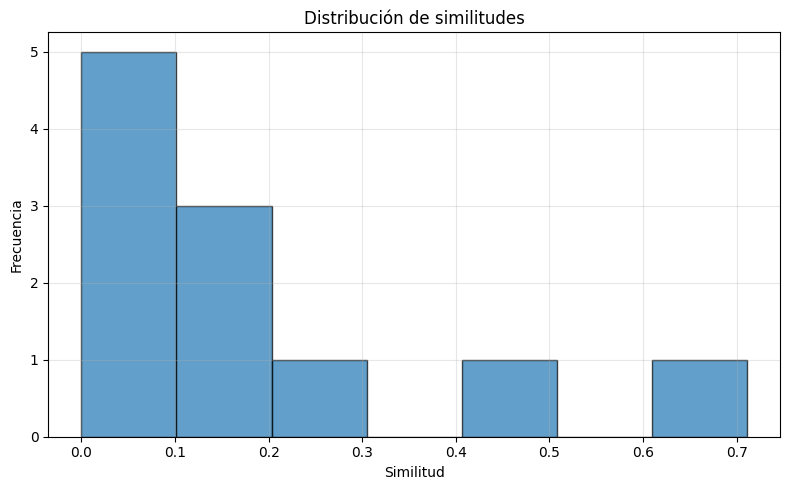

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(
    similitudes,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Embeding semántico

Batches: 100%|██████████| 1/1 [00:00<00:00, 45.19it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


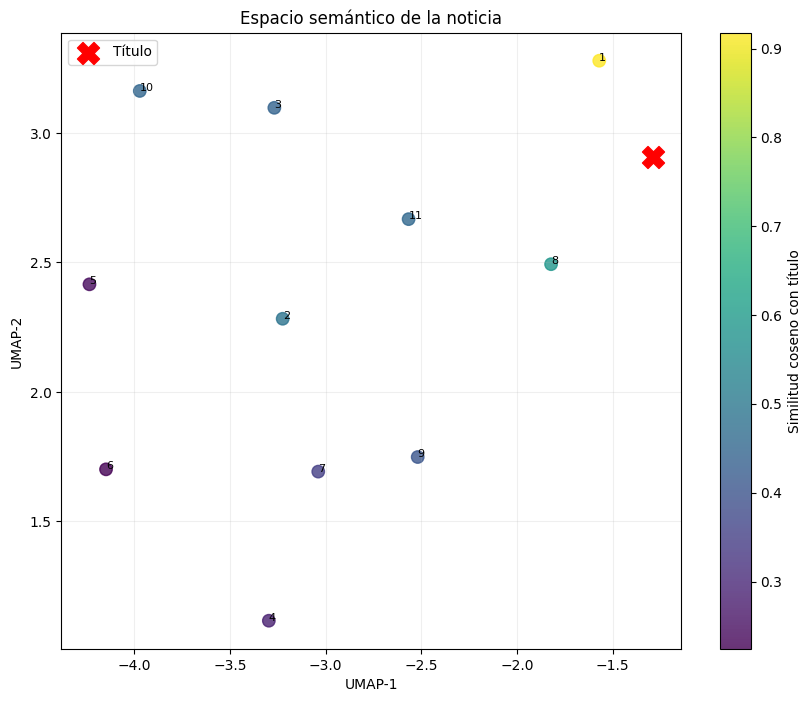

In [40]:
# corpus=cargar_datos(1)


similarities,embeddings=embedding_sentence_transformers(corpus)
embedding_2d=embedding_umap(similarities,embeddings, plot=True)

### Cross encoder

In [41]:
# corpus=cargar_datos(1)

probabilities = embedding_cross_encoder(corpus)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1568.71it/s]


In [42]:
probabilities

array([9.9988043e-01, 2.2439662e-01, 8.5739193e-05, 1.7540058e-02,
       1.2648782e-05, 1.2668230e-05, 3.1429091e-03, 6.4884096e-01,
       5.4612418e-04, 5.3114328e-04, 2.6828600e-05], dtype=float32)

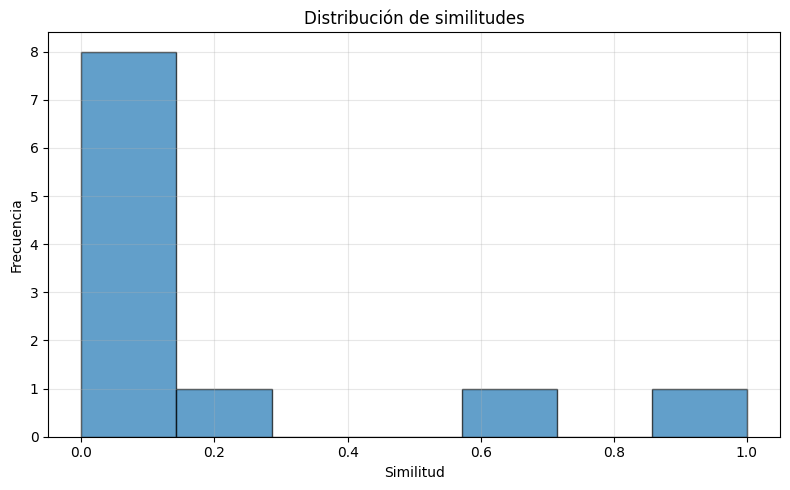

In [ ]:



plt.figure(figsize=(8, 5))

plt.hist(
    probabilities,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**COSAS QUE HE IDO PROBANDO**

----

In [51]:
import numpy as np
import pandas as pd

# =========================
# Parámetros globales
# =========================

N_ARCHIVOS = 63 # ajusta a tu caso

resultados = []

# =========================
# Loop sobre noticias
# =========================

for i in range(N_ARCHIVOS):

    try:
        noticia, corpus = cargar_datos(i)
        categoria=noticia["Categoría"]
        periodico=noticia["Periódico"]
        similarities, embeddings = embedding_sentence_transformers(corpus)

        similarities = np.array(similarities)

        # =========================
        # Métricas básicas
        # =========================

        media = similarities.mean()
        std = similarities.std()
        minimo = similarities.min()
        maximo = similarities.max()

        # porcentaje de frases relevantes
        umbral = 0.3
        relevancia = np.mean(similarities > umbral)

        # entropía (versión simple con softmax)
        exp_sim = np.exp(similarities)
        probs = exp_sim / np.sum(exp_sim)

        entropia = -np.sum(probs * np.log(probs + 1e-12))

        resultados.append({
            "id": i,
            "categoría": categoria,
            "periódico": periodico,
            "media_sim": media,
            "std_sim": std,
            "min_sim": minimo,
            "max_sim": maximo,
            "ratio_relevante": relevancia,
            "entropia": entropia
        })

    except Exception as e:
        print(f"Error en archivo {i}: {e}")

# =========================
# DataFrame final
# =========================

df = pd.DataFrame(resultados)

print(df.head())

# =========================
# Estadísticas globales
# =========================

print("\nResumen global:")
print(df.describe())

Batches: 100%|██████████| 1/1 [00:00<00:00,  2.88it/s]

   id      categoría  periódico  media_sim   std_sim   min_sim   max_sim  \
0   0  Internacional  20minutos   0.537468  0.075162  0.462306  0.612629   
1   1  Internacional  20minutos   0.355860  0.091845  0.187141  0.569737   
2   2  Internacional  20minutos   0.432090  0.069169  0.335965  0.495854   
3   3       Nacional  20minutos   0.433133  0.132524  0.091667  0.631324   
4   4       Nacional  20minutos   0.613924  0.134223  0.449059  0.906711   

   ratio_relevante  entropia  
0         1.000000  0.690331  
1         0.692308  3.253839  
2         1.000000  1.096290  
3         0.866667  2.699809  
4         1.000000  2.069614  

Resumen global:
              id  media_sim    std_sim    min_sim    max_sim  ratio_relevante  \
count  63.000000  63.000000  63.000000  63.000000  63.000000        63.000000   
mean   31.000000   0.434493   0.134758   0.214751   0.666919         0.764579   
std    18.330303   0.104218   0.059296   0.172618   0.116871         0.225663   
min     0.000000

In [52]:
df

,id,categoría,periódico,media_sim,std_sim,min_sim,max_sim,ratio_relevante,entropia
0,0,Internacional,20minutos,0.537468,0.075162,0.462306,0.612629,1.000000,0.690331
1,1,Internacional,20minutos,0.355860,0.091845,0.187141,0.569737,0.692308,3.253839
2,2,Internacional,20minutos,0.432090,0.069169,0.335965,0.495854,1.000000,1.096290
3,3,Nacional,20minutos,0.433133,0.132524,0.091667,0.631324,0.866667,2.699809
4,4,Nacional,20minutos,0.613924,0.134223,0.449059,0.906711,1.000000,2.069614
...,...,...,...,...,...,...,...,...,...
58,58,Nacional,RTVE,0.414611,0.006885,0.407725,0.421496,1.000000,0.693124
59,59,Nacional,RTVE,0.366899,0.115086,0.122666,0.522594,0.750000,2.073241
60,60,Cultura,RTVE,0.524821,0.009446,0.515376,0.534267,1.000000,0.693103
61,61,Cultura,RTVE,0.596486,0.068316,0.501354,0.658654,1.000000,1.096348


<Axes: >

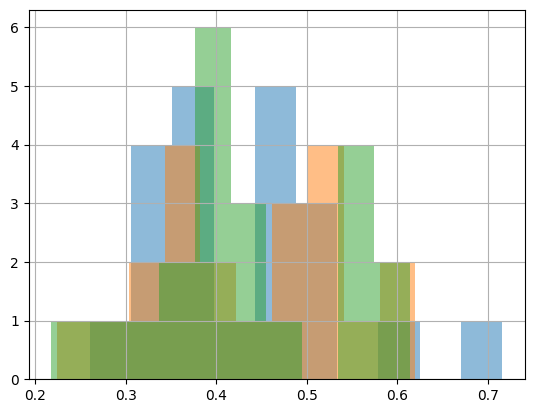

In [55]:
# df["media_sim"].hist()
df[df["categoría"]=="Cultura"]["media_sim"].hist(alpha=0.5, label="Cultura")
df[df["categoría"]=="Internacional"]["media_sim"].hist(alpha=0.5, label="Internacional")
df[df["categoría"]=="Nacional"]["media_sim"].hist(alpha=0.5, label="Nacional")

<Axes: >

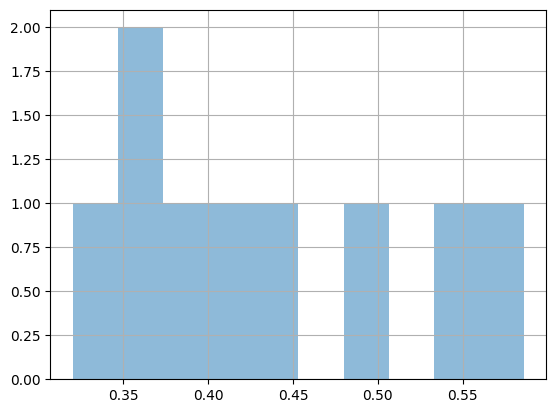

In [ ]:
# df[df["periódico"]=="20minutos"]["media_sim"].hist(alpha=0.5, label="Cultura")
df[df["periódico"]=="okdiario"]["media_sim"].hist(alpha=0.5, label="Cultura")
# df[df["periódico"]=="RTVE"]["media_sim"].hist(alpha=0.5, label="Cultura")





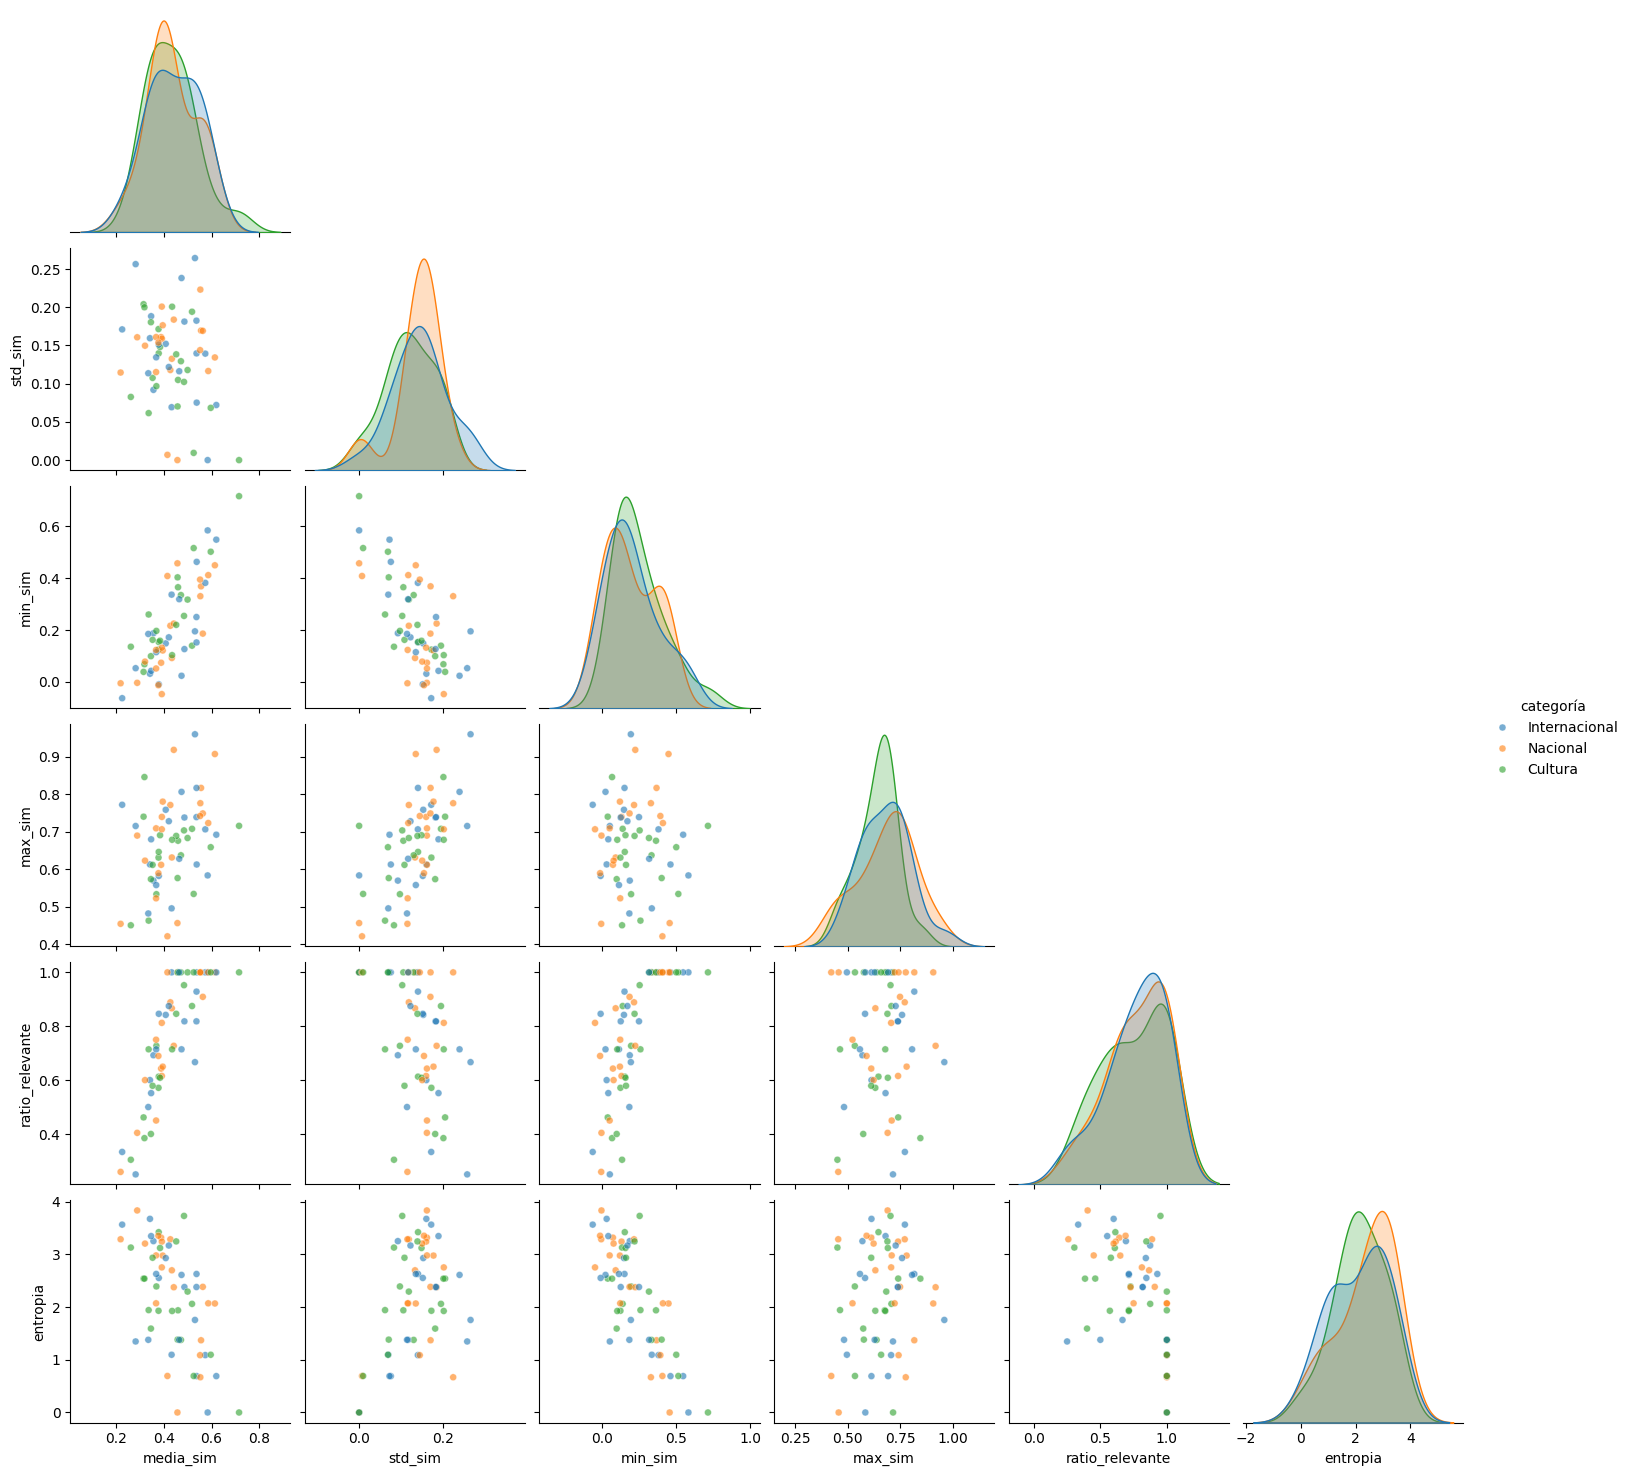

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Selección de variables
# =========================

cols = [
    "media_sim",
    "std_sim",
    "min_sim",
    "max_sim",
    "ratio_relevante",
    "entropia"
]

# =========================
# Pairplot
# =========================

sns.pairplot(
    df[cols + ["categoría"]],
    hue="categoría",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 25}
)

plt.show()

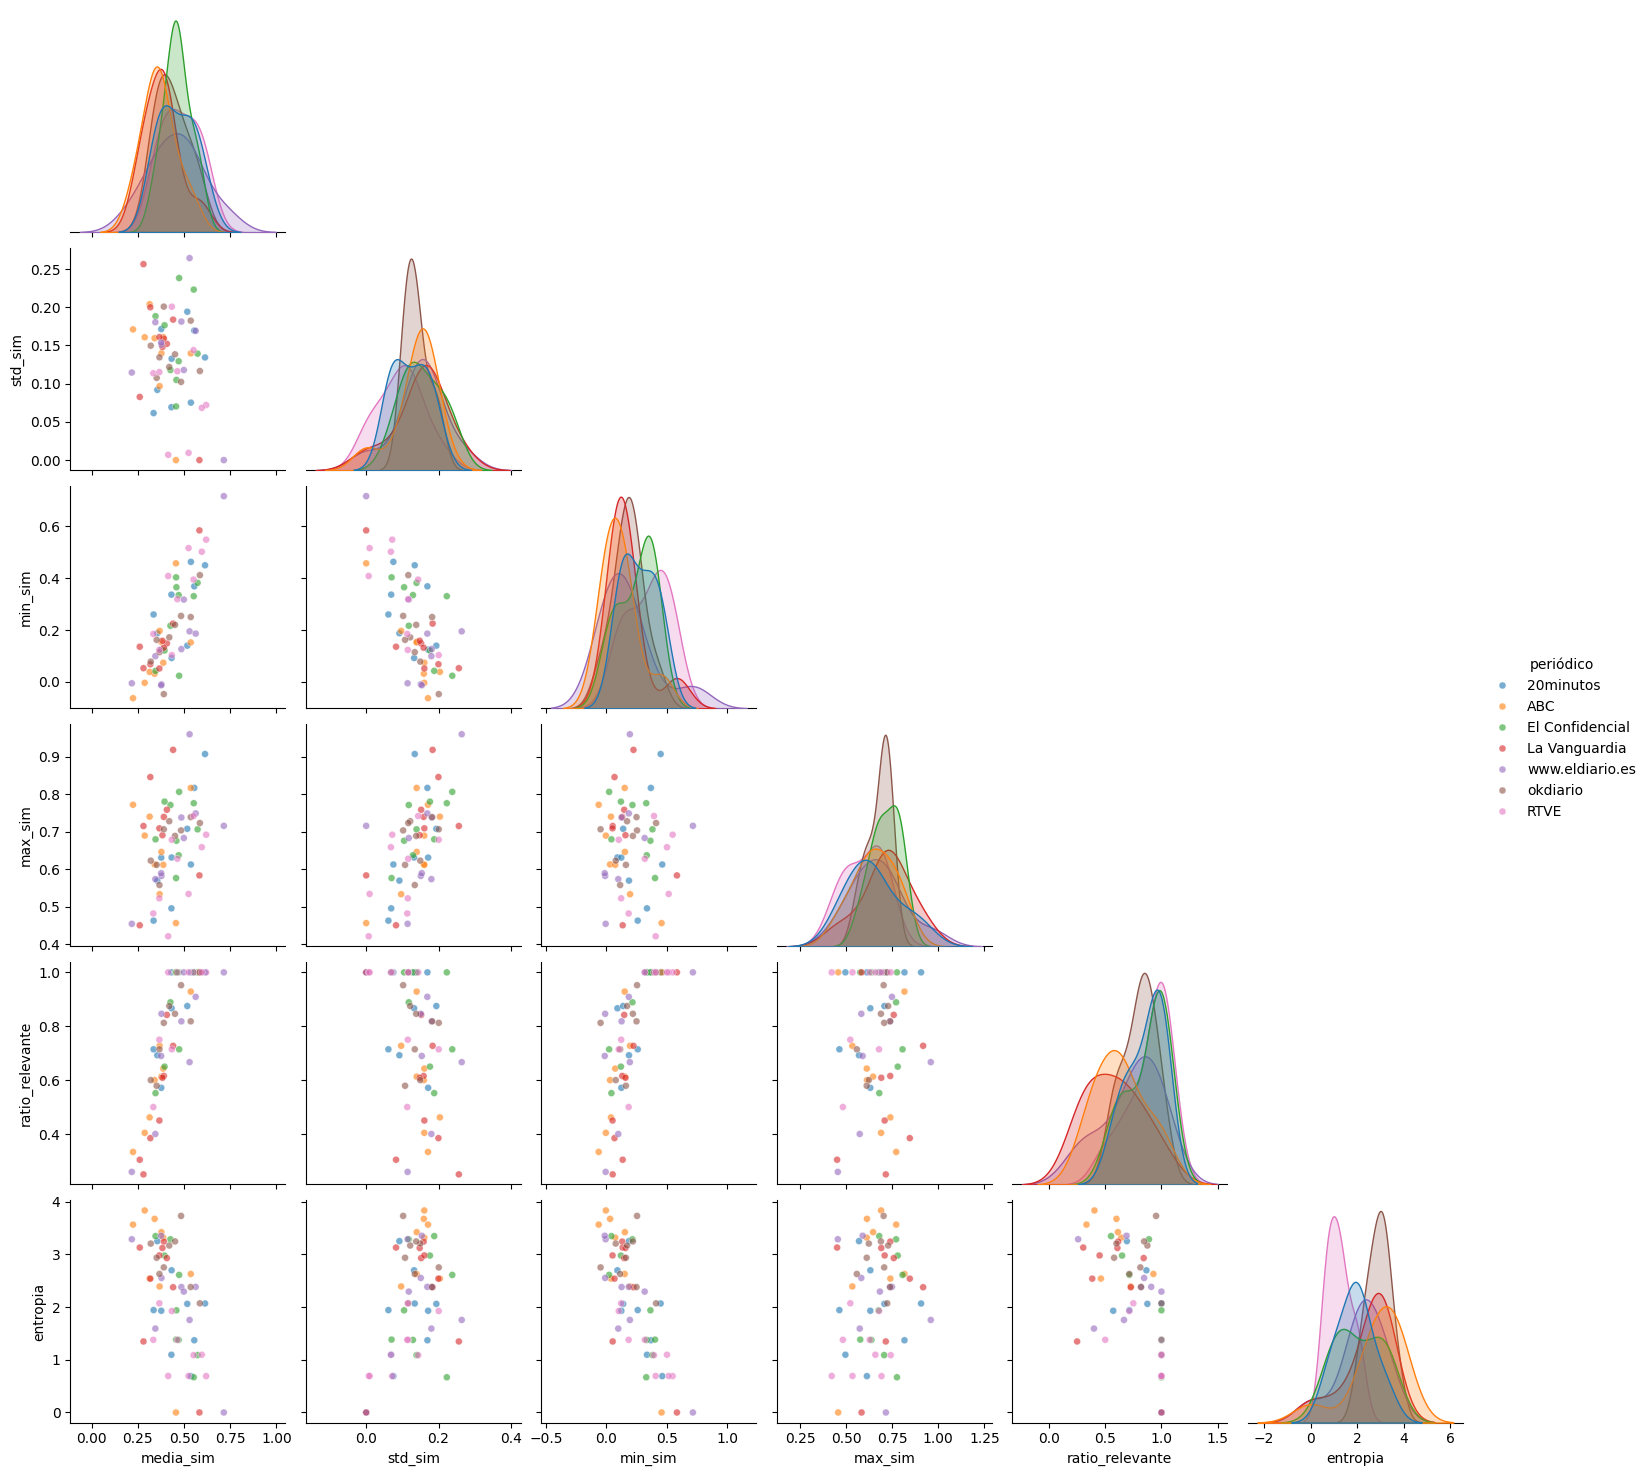

In [67]:
cols = [
    "media_sim",
    "std_sim",
    "min_sim",
    "max_sim",
    "ratio_relevante",
    "entropia"
]

# =========================
# Pairplot
# =========================

sns.pairplot(
    df[cols + ["periódico"]],
    hue="periódico",
    diag_kind="kde",
    corner=True,
    plot_kws={"alpha": 0.6, "s": 25}
)

plt.show()

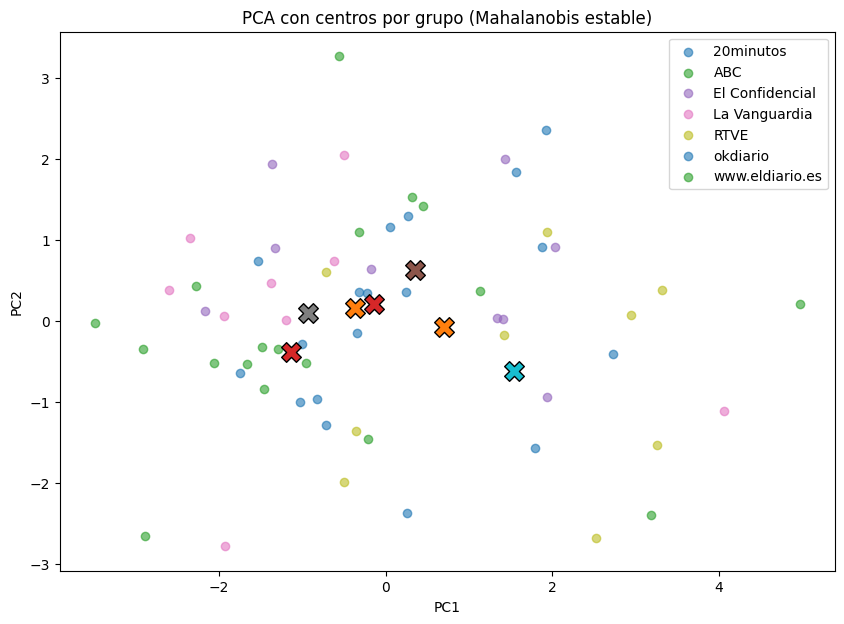

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis

# =========================
# Features
# =========================

cols = [
    "media_sim",
    "std_sim",
    "min_sim",
    "max_sim",
    "ratio_relevante",
    "entropia"
]

X = df[cols].dropna()
y = df.loc[X.index, "periódico"]

# =========================
# Escalado + PCA
# =========================

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["grupo"] = y.values

# =========================
# Covarianza GLOBAL (clave para evitar errores)
# =========================

cov_global = np.cov(X_pca.T)
inv_cov_global = np.linalg.pinv(cov_global)

# =========================
# Centros por grupo
# =========================

centros = df_pca.groupby("grupo")[["PC1", "PC2"]].mean()

# =========================
# Distancias Mahalanobis
# =========================

df_pca["mahalanobis"] = np.nan

for grupo in centros.index:

    subset_idx = df_pca["grupo"] == grupo
    subset = df_pca.loc[subset_idx, ["PC1", "PC2"]].values

    centro = centros.loc[grupo].values

    for i, x in zip(df_pca[subset_idx].index, subset):

        d = mahalanobis(x, centro, inv_cov_global)
        df_pca.loc[i, "mahalanobis"] = d

# =========================
# Plot
# =========================

plt.figure(figsize=(10, 7))

for grupo in centros.index:

    subset = df_pca[df_pca["grupo"] == grupo]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=grupo
    )

    plt.scatter(
        centros.loc[grupo, "PC1"],
        centros.loc[grupo, "PC2"],
        s=200,
        marker="X",
        edgecolor="black"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA con centros por grupo (Mahalanobis estable)")
plt.legend()
plt.show()

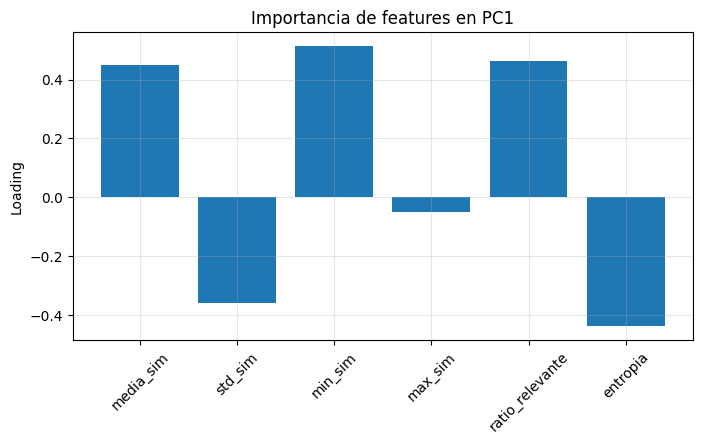

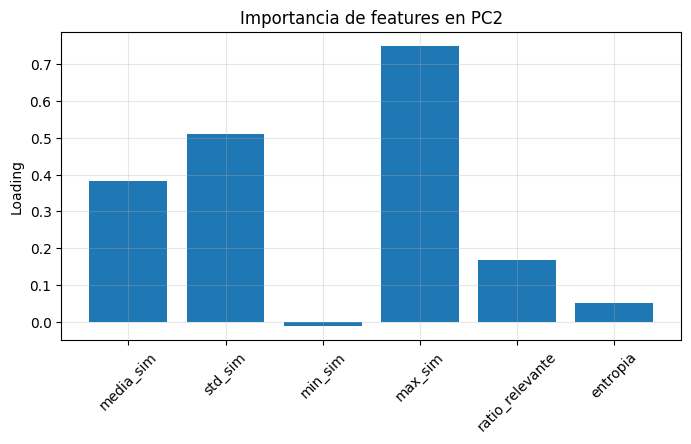

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# =========================
# Features
# =========================

cols = [
    "media_sim",
    "std_sim",
    "min_sim",
    "max_sim",
    "ratio_relevante",
    "entropia"
]

X = df[cols].dropna()

# Escalado
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
pca.fit(X_scaled)

# Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=cols,
    columns=["PC1", "PC2"]
)

# =========================
# Plot PC1
# =========================

plt.figure(figsize=(8, 4))
plt.bar(loadings.index, loadings["PC1"])
plt.xticks(rotation=45)
plt.title("Importancia de features en PC1")
plt.ylabel("Loading")
plt.grid(alpha=0.3)
plt.show()

# =========================
# Plot PC2
# =========================

plt.figure(figsize=(8, 4))
plt.bar(loadings.index, loadings["PC2"])
plt.xticks(rotation=45)
plt.title("Importancia de features en PC2")
plt.ylabel("Loading")
plt.grid(alpha=0.3)
plt.show()